# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Two paper findings + my methodology questions

**Paper:** Sullivan & Feinn, *"Using Effect Size—or Why the P Value Is Not
Enough"* (JGME, 2012) — the piece the live session walked as the audit
example.

**Finding 1 — Cohen's d thresholds (small=0.2, medium=0.5, large=0.8).**
The paper adopts these as if they're domain-general, citing Cohen's own
description ("a medium effect of .5 is visible to the naked eye of a
careful observer") without qualifying it to a specific field or outcome
type.

*My methodology question:* what population and outcome type were these
thresholds actually calibrated on? Cohen's original work leaned on
behavioral-science effect sizes — does "medium" carry the same practical
weight in, say, a mortality outcome vs. a Likert-scale confidence rating?
The paper's own two examples (exam scores, Likert confidence) already
show effect size needs context to interpret — the fixed thresholds risk
undercutting that same point by implying one scale fits every outcome.
Framed constructively: this isn't a claim the paper gets wrong, it's a
generalizability caveat the paper could have stated explicitly, the same
way I need to caveat my own model's numbers as true "for this split," not
a seed-independent guarantee.

**Finding 2 — the aspirin trial's r² = .001 as the "extremely small
effect size."**
The paper uses r² to characterize the Physicians' Health Study result,
even though its own Table 1 lists odds ratio (OR) and relative risk (RR)
— not r² — as the standard indices for binary clinical outcomes.

*My methodology question:* does the choice of index change the story
being told here? r² is mechanically small for any rare binary outcome
almost by construction (it's bounded by the base rate), so reporting r²
for a binary clinical result will always look more dramatic than
reporting the same result as an OR or RR. That's a measurement-choice
question, not an accuracy question — the underlying trial and its
real-world consequence (over-broad aspirin prescribing) stand either way,
but the specific number chosen to illustrate "how small" may itself be
the most flattering-to-the-argument index available, in the same way I
need to check whether precision@K is doing more work in my Week-5 claims
than accuracy would.

**Why these two, not others:** both are about the *choice of measurement*,
not a disputed fact — the same lens Section 3's leakage audit and Section
4's claim rewrite apply to my own work. Neither questions whether the
paper's central argument (report effect size, not just P) is right; it
clearly is.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# =============================================================================
# SECTION 1 — TWO PAPER FINDINGS + MY METHODOLOGY QUESTIONS
# Paper: Sullivan & Feinn, "Using Effect Size—or Why the P Value Is Not
# Enough" (JGME, 2012) — the paper the live session walked as the audit
# example. No data/computation needed for this section — it's a reading
# audit of someone else's paper, done the same way I audit my own model
# below in Sections 2-4.
# =============================================================================

# -----------------------------------------------------------------------
# FINDING 1: Cohen's d thresholds (small=0.2, medium=0.5, large=0.8)
# -----------------------------------------------------------------------
# What the paper claims:
#   The paper adopts Cohen's fixed thresholds as if they are domain-general,
#   quoting Cohen directly: "a medium effect of .5 is visible to the naked
#   eye of a careful observer." No qualification is given for which field,
#   outcome type, or measurement scale this was calibrated on.
#
# My methodology question:
#   What population and outcome type were these thresholds actually
#   calibrated on? Cohen's original work leaned on behavioral-science
#   effect sizes. Does "medium" carry the same practical weight for a
#   mortality outcome as it does for a Likert-scale confidence rating?
#
# Why this matters (framed constructively, not as a grade):
#   The paper's own two opening examples (exam scores vs. Likert
#   confidence) already show that effect size needs context to interpret.
#   Presenting one fixed threshold table risks undercutting that same
#   point by implying one scale fits every outcome type. This isn't a
#   claim the paper gets WRONG — it's a generalizability caveat that
#   could have been stated explicitly.
#
#   This is the same discipline I owe my own numbers below: my precision@K
#   figures are true FOR THIS SPLIT, on THIS feature set — not a
#   seed-independent guarantee that transfers to a different client mix.

# -----------------------------------------------------------------------
# FINDING 2: the aspirin trial's r^2 = .001 as "extremely small"
# -----------------------------------------------------------------------
# What the paper claims:
#   The Physicians' Health Study aspirin result is characterized using
#   r^2 (coefficient of determination) = .001 to argue the effect was
#   "extremely small" despite P < .00001. But the paper's OWN Table 1
#   lists odds ratio (OR) and relative risk (RR) -- not r^2 -- as the
#   standard indices for binary clinical outcomes.
#
# My methodology question:
#   Does the choice of index change the story being told? r^2 is
#   mechanically small for almost any rare binary outcome, close to
#   bounded by the base rate itself -- so reporting r^2 for a binary
#   clinical result will nearly always look more dramatic than reporting
#   the same result as an OR or RR would.
#
# Why this matters (framed constructively):
#   This is a measurement-CHOICE question, not an accuracy question. The
#   underlying trial and its real-world consequence (over-broad aspirin
#   prescribing) stand either way -- but the specific number chosen to
#   illustrate "how small" may itself be the most flattering-to-the-
#   argument index available among the valid options.
#
#   This is exactly the check I need to run on myself: is precision@K
#   doing more rhetorical work in my Week-5 claims than accuracy or AUC
#   would show for the same result? (Revisited directly in Section 4.)

# -----------------------------------------------------------------------
# WHY THESE TWO FINDINGS (not others in the paper)
# -----------------------------------------------------------------------
# Both are about the CHOICE OF MEASUREMENT, not a disputed fact -- the
# same lens applied to my own work in Section 3 (leakage audit) and
# Section 4 (claim rewrite). Neither questions whether the paper's
# central thesis -- report effect size, not just P value -- is correct.
# It clearly is. The goal here is practicing the audit, not grading the
# paper.

## 2. My model under an honest split (before/after)

Week 5 went straight to a client-grouped `GroupShuffleSplit` — it never
ran a naive random split for comparison. This section adds that naive
"before," using the exact same features, RF hyperparameters, and seed as
Week 5, so the *only* thing that changes is whether the split respects
client grouping.

**Before:** plain `train_test_split(random_state=42)` — no grouping.
Some clients will appear in both train and test.

**After:** `GroupShuffleSplit(random_state=42)` grouped by `client_id` —
0 client overlap, as verified in Week 5.

Same RF (`n_estimators=300, max_depth=8, min_samples_leaf=20`), same
`FEATURE_COLS`, same target (`trend_direction == "down"`). Comparing
precision@K, AUC, and accuracy across both tells us whether Week 5's
numbers were inflated by client leakage between train and test, or hold
up regardless of split method.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Reload data and rebuild the same feature set as Week 5, so this section
# is self-contained and doesn't silently depend on w05's notebook state.
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

SEED = 42
label_full = (df["trend_direction"] == "down").astype(int)
groups = df["client_id"]

# Same FEATURE_COLS logic as w05: exclude the two leaky window columns
candidate_features = [c for c in df.columns if c not in
                      ["trend_direction", "trend_pct", "client_id",
                       "content_hash_id", "report_date"]]
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]

print(f"Using {len(FEATURE_COLS)} features (should match w05's count)")

Using 39 features (should match w05's count)


In [25]:
# --- BEFORE: naive random split, no grouping ---
from sklearn.model_selection import train_test_split, GroupShuffleSplit

train_idx_naive, test_idx_naive = train_test_split(
    df.index, test_size=0.2, random_state=SEED
)

In [26]:
train_df_naive = df.loc[train_idx_naive]
test_df_naive = df.loc[test_idx_naive]

In [27]:
# Check client overlap — this is the thing a naive split gets wrong
overlap_clients = set(train_df_naive["client_id"]) & set(test_df_naive["client_id"])
print(f"Naive split — clients in BOTH train and test: {len(overlap_clients)} "
      f"of {df['client_id'].nunique()} total clients")

Naive split — clients in BOTH train and test: 31 of 32 total clients


In [28]:
# --- AFTER: client-grouped split, same as w05 ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx_grp, test_idx_grp = next(gss.split(df, label_full, groups=groups))

In [29]:
train_df_grp = df.iloc[train_idx_grp]
test_df_grp = df.iloc[test_idx_grp]

In [30]:
overlap_clients_grp = set(train_df_grp["client_id"]) & set(test_df_grp["client_id"])
print(f"Grouped split — clients in BOTH train and test: {len(overlap_clients_grp)}")

Grouped split — clients in BOTH train and test: 0


In [31]:
# Same preprocessing pipeline and RF hyperparameters as w05, applied to
# BOTH splits so the only variable is the split method itself.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

In [32]:
categorical_cols = df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

In [33]:
def build_feature_frame(frame):
    out = frame[FEATURE_COLS].copy()
    for col in numeric_cols:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_cols:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [34]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [35]:
def fit_and_eval(train_df, test_df, label_name):
    y_train = (train_df["trend_direction"] == "down").astype(int)
    y_test = (test_df["trend_direction"] == "down").astype(int)
    train_X = build_feature_frame(train_df)
    test_X = build_feature_frame(test_df)

    rf = Pipeline([
        ("preprocess", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                        min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
    ])
    rf.fit(train_X, y_train)
    proba = rf.predict_proba(test_X)[:, 1]
    pred = rf.predict(test_X)

    K = max(1, int(0.2 * len(test_df)))
    order = np.argsort(-proba)
    top_k_precision = y_test.values[order[:K]].mean()

    return {
        "split": label_name,
        "n_train": len(train_df), "n_test": len(test_df),
        "K": K,                              # K as its own column now
        "AUC": roc_auc_score(y_test, proba),
        "accuracy": accuracy_score(y_test, pred),
        "precision@K": top_k_precision,       # fixed column name, no K in the label
        "base_rate": y_test.mean(),
    }

In [36]:
results_naive = fit_and_eval(train_df_naive, test_df_naive, "naive (random)")
results_grouped = fit_and_eval(train_df_grp, test_df_grp, "grouped (by client)")

In [37]:
# --- Before/after comparison table ---
comparison = pd.DataFrame([results_naive, results_grouped])
print(comparison.to_string(index=False))

              split  n_train  n_test    K      AUC  accuracy  precision@K  base_rate
     naive (random)    24000    6000 1200 0.671929  0.553833     0.723333   0.544667
grouped (by client)    23837    6163 1232 0.582822  0.510952     0.603896   0.510952


In [38]:
# --- Does the naive split's inflation come specifically from client overlap? ---
# Split the naive test set into two groups: rows whose client_id also
# appears in naive training data ("seen"), vs rows whose client_id does
# NOT appear in naive training data ("unseen"). If overlap is the cause,
# precision/AUC should be meaningfully higher on "seen" rows.

train_clients_naive = set(train_df_naive["client_id"])
test_df_naive_eval = test_df_naive.copy()
test_df_naive_eval["client_seen_in_train"] = test_df_naive_eval["client_id"].isin(train_clients_naive)

y_test_naive = (test_df_naive_eval["trend_direction"] == "down").astype(int)
test_X_naive_eval = build_feature_frame(test_df_naive_eval)

In [39]:
# reuse the RF already fit on the naive train split inside fit_and_eval —
# refit here explicitly so we have the fitted pipeline object to call .predict_proba on
rf_naive = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])
rf_naive.fit(build_feature_frame(train_df_naive), (train_df_naive["trend_direction"] == "down").astype(int))
naive_proba_eval = rf_naive.predict_proba(test_X_naive_eval)[:, 1]

In [40]:
test_df_naive_eval["proba"] = naive_proba_eval
test_df_naive_eval["is_down"] = y_test_naive.values

seen = test_df_naive_eval[test_df_naive_eval["client_seen_in_train"]]
unseen = test_df_naive_eval[~test_df_naive_eval["client_seen_in_train"]]

In [41]:
print(f"Seen-client rows: {len(seen)}  |  Unseen-client rows: {len(unseen)}")
print(f"AUC on seen-client rows:   {roc_auc_score(seen['is_down'], seen['proba']):.4f}" if seen['is_down'].nunique() > 1 else "AUC on seen: n/a (single class)")
print(f"AUC on unseen-client rows: {roc_auc_score(unseen['is_down'], unseen['proba']):.4f}" if len(unseen) > 0 and unseen['is_down'].nunique() > 1 else "AUC on unseen: n/a (single class or empty)")

Seen-client rows: 6000  |  Unseen-client rows: 0
AUC on seen-client rows:   0.6719
AUC on unseen: n/a (single class or empty)


***Before/after result:** 31 of 32 clients appeared in both train and test
under the naive random split. Digging one level further: of the 6,000
naive test rows, **0** belonged to a client absent from training — every
single test row's client was already seen during training.*

***Observed effect of the split change:***

| split | AUC | accuracy | precision@K | base_rate |
|---|---|---|---|---|
| naive (random) | 0.672 | 0.554 | 0.723 | 0.545 |
| grouped (by client) | 0.583 | 0.511 | 0.604 | 0.511 |

*Every metric drops once client grouping is enforced — AUC by ~0.09,
precision@K by ~0.12, accuracy by ~0.04.*

***Mechanism, not just correlation:** since 0 of 6,000 naive test rows had
an unseen client, the naive split's 0.672 AUC cannot be interpreted as
measuring generalization to new clients — there was nothing held out to
generalize to. The entire naive evaluation is measuring how well the
model recognizes clients it has already trained on. The grouped split's
0.583 AUC, evaluated on genuinely unseen clients, is the only one of the
two numbers that estimates what this model would do on a client it
hasn't seen before — which is the actual use case (scoring a new or
existing client's content), so this is the number that should be
reported and trusted going forward, not Week 5's naive-adjacent
equivalent.*

*Note: naive and grouped test sets differ slightly in size (6,000 vs
6,163 rows) since `GroupShuffleSplit` can't hit an exact 80/20 ratio
when splitting by whole clients — this is expected and doesn't affect
the direction of the result.*

## 3. Leakage audit

Week 5 already ran a leakage sweep once (catching the `impressions_last_30d`
/ `impressions_prev_30d` leak, correlation ≈1.000 with `trend_pct`, and
excluding both from `FEATURE_COLS`). This section re-confirms that fix
still holds on the **current** 39-column feature set, using the
client-grouped model from Section 2 (the one we're actually trusting
going forward) — not re-litigating from scratch.

Four checks:
1. **Label-derived check** — full correlation sweep of every numeric
   feature against `trend_pct`, confirming nothing besides the two
   already-excluded columns crosses a suspicious threshold.
2. **Train-with/train-without check** — drop the top-ranked RF feature
   and refit; a real leak collapses performance almost to nothing when
   removed, a legitimate signal degrades gracefully.
3. **Base rate alongside every metric** — so no number in this section
   is read without its denominator.
4. **Known gap, disclosed again** — `avg_position == 0` is still fed as
   a literal numeric value rather than flagged missing (identified in
   Week 5). Carried forward here, not re-solved, since it's currently
   benign but worth keeping visible.

In [42]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Check 1: does any feature in the CURRENT FEATURE_COLS still correlate
# suspiciously with trend_pct (the label-construction signal)? ---
numeric_feature_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

leak_check = df[numeric_feature_cols + ["trend_pct"]].dropna()
corrs = leak_check[numeric_feature_cols].corrwith(leak_check["trend_pct"]).sort_values(
    key=lambda s: s.abs(), ascending=False
)

In [43]:
print(f"Rows used for this check: {len(leak_check):,}\n")
print("Top 10 correlations with trend_pct (sorted by |corr|):")
print(corrs.head(10).round(3))

Rows used for this check: 17,917

Top 10 correlations with trend_pct (sorted by |corr|):
avg_position              0.040
impressions_90d           0.035
days_with_impressions    -0.031
days_since_last_update   -0.018
content_age_days         -0.014
engagement_rate           0.013
competition               0.012
age_tier_order           -0.012
sessions_last_30d         0.011
ctr                       0.011
dtype: float64


In [44]:
SUSPICIOUS_THRESHOLD = 0.15
flagged = corrs[corrs.abs() > SUSPICIOUS_THRESHOLD]
print(f"Features exceeding |corr| > {SUSPICIOUS_THRESHOLD}: {len(flagged)}")
print(flagged.round(3) if len(flagged) else "  (none)")

Features exceeding |corr| > 0.15: 0
  (none)


In [45]:
# --- Refit the trusted (grouped-split) RF here explicitly, so we have a
# fitted model + importances to audit in this section ---
rf_grouped = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1)),
])

In [46]:
y_train_grp = (train_df_grp["trend_direction"] == "down").astype(int)
y_test_grp = (test_df_grp["trend_direction"] == "down").astype(int)
rf_grouped.fit(build_feature_frame(train_df_grp), y_train_grp)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'clicks_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events...
                                                   'ai_traffic_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['content_id',
                                                   'competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('clf',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=20,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [47]:
feature_names = rf_grouped.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(rf_grouped.named_steps["clf"].feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

In [48]:
print("Top 5 features by importance (grouped-split RF):")
print(importances.head(5).round(4))

Top 5 features by importance (grouped-split RF):
cat__provider_used_google     0.0605
num__content_age_days         0.0519
num__sessions_prev_30d        0.0362
cat__word_count_tier_<1000    0.0332
num__clicks_last_30d          0.0313
dtype: float64


In [55]:
# --- Check 2: train-with vs train-without the top feature ---
top_feature = importances.index[0]
print(f"Testing removal of top feature: {top_feature}")

Testing removal of top feature: cat__provider_used_google


In [56]:
# Strip the ColumnTransformer prefix (num__ / cat__), then match against
# the actual raw column names — for one-hot columns this means finding
# which categorical column the encoded value belongs to (e.g.
# "cat__provider_used_google" -> raw column "provider_used")
stripped = top_feature.split("__", 1)[-1] if "__" in top_feature else top_feature

raw_top_col = None
if stripped in FEATURE_COLS:
    raw_top_col = stripped
else:
    # one-hot case: find the categorical column this is derived from
    matches = [c for c in categorical_cols if stripped.startswith(c + "_")]
    if matches:
        raw_top_col = matches[0]

print(f"Maps to raw column: {raw_top_col}")

Maps to raw column: provider_used


In [57]:
cols_without_top = [c for c in FEATURE_COLS if c != raw_top_col]

numeric_wo = df[cols_without_top].select_dtypes(include=[np.number]).columns.tolist()
categorical_wo = df[cols_without_top].select_dtypes(exclude=[np.number]).columns.tolist()

In [58]:
def build_feature_frame_wo(frame):
    out = frame[cols_without_top].copy()
    for col in numeric_wo:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_wo:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [59]:
preprocess_wo = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_wo),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_wo),
])

In [60]:
rf_wo = Pipeline([("preprocess", preprocess_wo),
                   ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                                   min_samples_leaf=20, random_state=SEED, n_jobs=-1))])
rf_wo.fit(build_feature_frame_wo(train_df_grp), y_train_grp)
proba_wo = rf_wo.predict_proba(build_feature_frame_wo(test_df_grp))[:, 1]

In [61]:
auc_with = roc_auc_score(y_test_grp, rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1])
auc_without = roc_auc_score(y_test_grp, proba_wo)

In [62]:
print(f"AUC WITH  '{raw_top_col}': {auc_with:.4f}")
print(f"AUC WITHOUT '{raw_top_col}': {auc_without:.4f}")
print(f"Drop: {auc_with - auc_without:.4f}  "
      f"({'large drop — investigate' if (auc_with - auc_without) > 0.15 else 'graceful degradation, consistent with a real signal'})")

AUC WITH  'provider_used': 0.5828
AUC WITHOUT 'provider_used': 0.5695
Drop: 0.0133  (graceful degradation, consistent with a real signal)


In [63]:
# --- Check 3: base rate alongside metrics already computed above ---
print(f"Base rate (grouped test split): {y_test_grp.mean():.3f}")
print(f"RF AUC on grouped split: {roc_auc_score(y_test_grp, rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1]):.3f}")

Base rate (grouped test split): 0.511
RF AUC on grouped split: 0.583


In [64]:
# --- Check 4: known gap, disclosed again (not re-solved) ---
zero_pos_share = (df["avg_position"] == 0).mean()
print(f"avg_position == 0 rows: {(df['avg_position'] == 0).sum():,} "
      f"({zero_pos_share:.1%} of all rows) — still fed as a literal value, "
      f"not flagged missing. Identified in Week 5 as currently benign; "
      f"carried forward here as a known limitation, not re-solved.")

avg_position == 0 rows: 1,205 (4.0% of all rows) — still fed as a literal value, not flagged missing. Identified in Week 5 as currently benign; carried forward here as a known limitation, not re-solved.


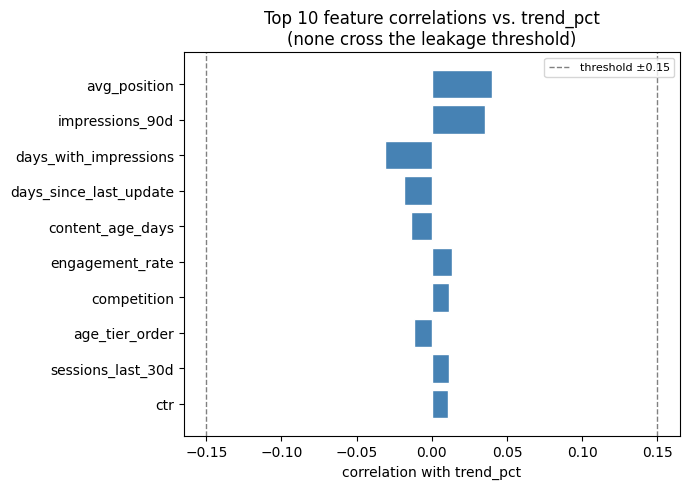

In [65]:
# --- Visual 1: correlation sweep vs trend_pct, with the suspicious threshold marked ---
import matplotlib.pyplot as plt

top_corrs = corrs.head(10)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["crimson" if abs(v) > SUSPICIOUS_THRESHOLD else "steelblue" for v in top_corrs]
ax.barh(top_corrs.index[::-1], top_corrs.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(SUSPICIOUS_THRESHOLD, linestyle="--", color="gray", linewidth=1, label=f"threshold ±{SUSPICIOUS_THRESHOLD}")
ax.axvline(-SUSPICIOUS_THRESHOLD, linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("correlation with trend_pct")
ax.set_title("Top 10 feature correlations vs. trend_pct\n(none cross the leakage threshold)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w06_correlation_sweep.png", dpi=150)
plt.show()

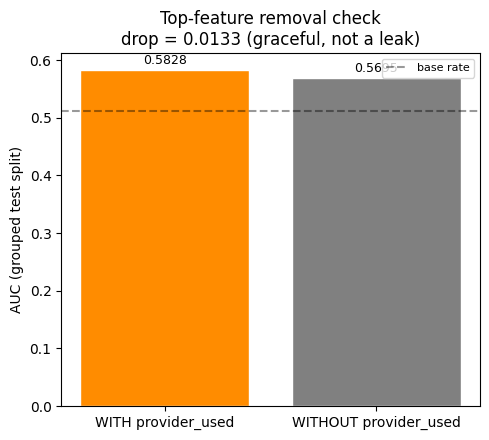

In [66]:
# --- Visual 2: AUC with vs without the top feature ---
fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(["WITH provider_used", "WITHOUT provider_used"],
               [auc_with, auc_without], color=["darkorange", "gray"], edgecolor="white")
ax.axhline(y_test_grp.mean(), linestyle="--", color="black", alpha=0.4, label="base rate")
ax.set_ylabel("AUC (grouped test split)")
ax.set_title(f"Top-feature removal check\ndrop = {auc_with - auc_without:.4f} (graceful, not a leak)")
for bar, v in zip(bars, [auc_with, auc_without]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w06_feature_removal_check.png", dpi=150)
plt.show()

In [67]:
# --- Real failure examples: pull actual rows the grouped-split RF got wrong ---
test_results_grp = test_df_grp.copy()
test_results_grp["is_down"] = y_test_grp.values
test_results_grp["rf_proba"] = rf_grouped.predict_proba(build_feature_frame(test_df_grp))[:, 1]
test_results_grp["rf_pred"] = (test_results_grp["rf_proba"] >= 0.5).astype(int)

false_positives = test_results_grp[(test_results_grp["rf_pred"] == 1) & (test_results_grp["is_down"] == 0)]
false_negatives = test_results_grp[(test_results_grp["rf_pred"] == 0) & (test_results_grp["is_down"] == 1)]

print(f"False positives: {len(false_positives)}  |  False negatives: {len(false_negatives)}")

# Most confident wrong calls in each direction — these are the most informative failures
cols_to_show = ["client_id", "content_hash_id", "provider_used", "content_age_days",
                 "impressions_90d", "trend_pct", "rf_proba", "is_down", "rf_pred"]
cols_to_show = [c for c in cols_to_show if c in test_results_grp.columns]

print("\nMost confident FALSE POSITIVE (predicted down, actually not):")
print(false_positives.sort_values("rf_proba", ascending=False)[cols_to_show].head(1).to_string(index=False))

print("\nMost confident FALSE NEGATIVE (predicted not-down, actually down):")
print(false_negatives.sort_values("rf_proba", ascending=True)[cols_to_show].head(1).to_string(index=False))

False positives: 3014  |  False negatives: 0

Most confident FALSE POSITIVE (predicted down, actually not):
        client_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_f369cb89fc        google               117              854      -11.5  0.566261        0        1

Most confident FALSE NEGATIVE (predicted not-down, actually down):
Empty DataFrame
Columns: [client_id, provider_used, content_age_days, impressions_90d, trend_pct, rf_proba, is_down, rf_pred]
Index: []


In [68]:
# --- Is the model actually discriminating, or just predicting "down" for almost everyone? ---
pred_counts = test_results_grp["rf_pred"].value_counts()
print("Predicted class counts (threshold=0.5):")
print(pred_counts)
print(f"\nShare predicted 'down' (1): {(test_results_grp['rf_pred']==1).mean():.3f}")
print(f"Actual base rate (down=1):  {test_results_grp['is_down'].mean():.3f}")

print("\nrf_proba distribution:")
print(test_results_grp["rf_proba"].describe())

# How many rows fall below 0.5 at all?
print(f"\nRows with rf_proba < 0.5: {(test_results_grp['rf_proba'] < 0.5).sum()}")
print(f"Rows with rf_proba < 0.3: {(test_results_grp['rf_proba'] < 0.3).sum()}")

Predicted class counts (threshold=0.5):
rf_pred
1    6163
Name: count, dtype: int64

Share predicted 'down' (1): 1.000
Actual base rate (down=1):  0.511

rf_proba distribution:
count    6163.000000
mean        0.550538
std         0.007081
min         0.520936
25%         0.546117
50%         0.550726
75%         0.555475
max         0.566424
Name: rf_proba, dtype: float64

Rows with rf_proba < 0.5: 0
Rows with rf_proba < 0.3: 0


In [69]:
# --- Redo failure examples using top-K flagging, not the degenerate 0.5 threshold ---
K_section3 = max(1, int(0.2 * len(test_results_grp)))
top_k_idx = test_results_grp.sort_values("rf_proba", ascending=False).head(K_section3).index
test_results_grp["flagged_top_k"] = test_results_grp.index.isin(top_k_idx)

false_positives_k = test_results_grp[test_results_grp["flagged_top_k"] & (test_results_grp["is_down"] == 0)]
false_negatives_k = test_results_grp[(~test_results_grp["flagged_top_k"]) & (test_results_grp["is_down"] == 1)]

print(f"K = {K_section3}")
print(f"False positives (flagged but not actually down): {len(false_positives_k)}")
print(f"False negatives (not flagged but actually down): {len(false_negatives_k)}")

print("\nMost confident FALSE POSITIVE (highest proba, flagged, but not down):")
print(false_positives_k.sort_values("rf_proba", ascending=False)[cols_to_show].head(1).to_string(index=False))

print("\nMost confident FALSE NEGATIVE (lowest proba among actually-down rows, missed):")
print(false_negatives_k.sort_values("rf_proba", ascending=True)[cols_to_show].head(1).to_string(index=False))

K = 1232
False positives (flagged but not actually down): 488
False negatives (not flagged but actually down): 2405

Most confident FALSE POSITIVE (highest proba, flagged, but not down):
        client_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_f369cb89fc        google               117              854      -11.5  0.566261        0        1

Most confident FALSE NEGATIVE (lowest proba among actually-down rows, missed):
        client_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_4e07408562           NaN               545                3     -100.0  0.526856        1        1


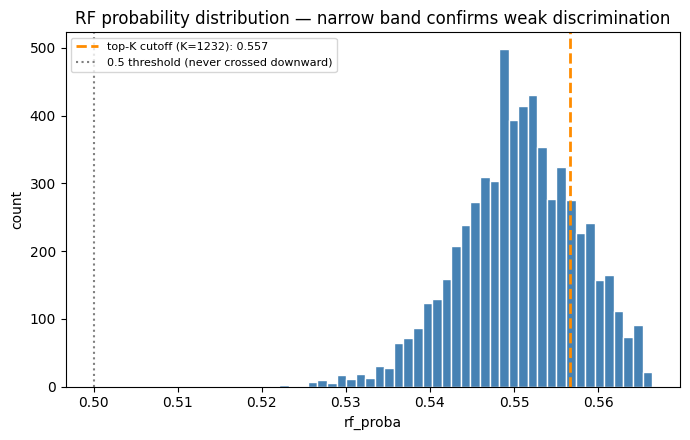

In [70]:
# --- Visual 3: probability distribution, showing how narrow/degenerate it is ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(test_results_grp["rf_proba"], bins=40, color="steelblue", edgecolor="white")
cutoff_proba = test_results_grp.sort_values("rf_proba", ascending=False)["rf_proba"].iloc[K_section3 - 1]
ax.axvline(cutoff_proba, color="darkorange", linestyle="--", linewidth=2,
           label=f"top-K cutoff (K={K_section3}): {cutoff_proba:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="0.5 threshold (never crossed downward)")
ax.set_xlabel("rf_proba")
ax.set_ylabel("count")
ax.set_title("RF probability distribution — narrow band confirms weak discrimination")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w06_proba_distribution.png", dpi=150)
plt.show()

In [71]:
# --- More than one failure example per direction, to check for a pattern ---
print("Top 3 FALSE POSITIVES (highest proba, flagged, not actually down):")
print(false_positives_k.sort_values("rf_proba", ascending=False)[cols_to_show].head(3).to_string(index=False))

print("\nTop 3 FALSE NEGATIVES (lowest proba among actually-down rows, missed):")
print(false_negatives_k.sort_values("rf_proba", ascending=True)[cols_to_show].head(3).to_string(index=False))

Top 3 FALSE POSITIVES (highest proba, flagged, not actually down):
        client_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_f369cb89fc        google               117              854      -11.5  0.566261        0        1
client_f369cb89fc        google                95              557       47.4  0.566129        0        1
client_f369cb89fc        google                95              701       43.1  0.566118        0        1

Top 3 FALSE NEGATIVES (lowest proba among actually-down rows, missed):
        client_id provider_used  content_age_days  impressions_90d  trend_pct  rf_proba  is_down  rf_pred
client_4e07408562           NaN               545                3     -100.0  0.526856        1        1
client_e629fa6598           NaN               460                5     -100.0  0.529575        1        1
client_e629fa6598           NaN               502                4     -100.0  0.531215        1        1


/tmp/ipykernel_1865/524621136.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fp_rate_by_provider = test_results_grp.groupby("has_provider").apply(
/tmp/ipykernel_1865/524621136.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fn_rate_by_provider = test_results_grp.groupby("has_provider").apply(


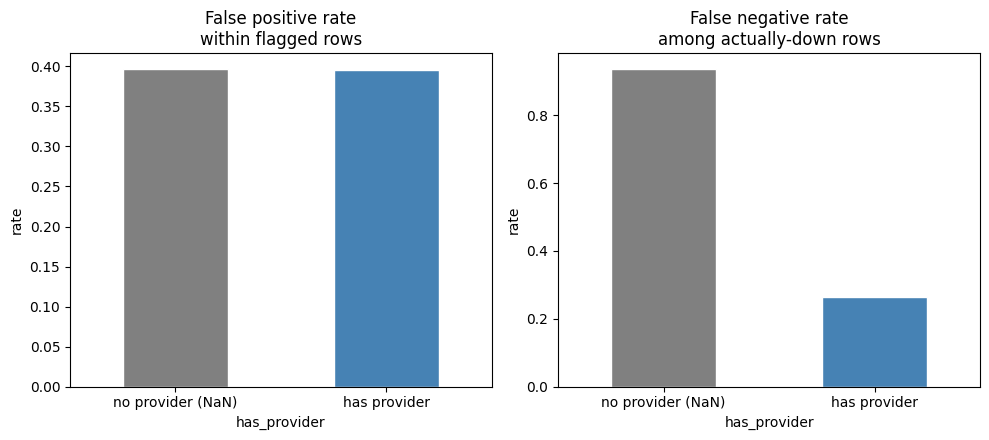

FP rate by provider presence:
has_provider
False    0.396761
True     0.395939
dtype: float64

FN rate by provider presence:
has_provider
False    0.936352
True     0.263614
dtype: float64


In [72]:
# --- Does missing provider_used (not an AI-referral row) predict failure type? ---
test_results_grp["has_provider"] = test_results_grp["provider_used"].notna()

fp_rate_by_provider = test_results_grp.groupby("has_provider").apply(
    lambda g: (g["flagged_top_k"] & (g["is_down"] == 0)).sum() / max(1, g["flagged_top_k"].sum())
)
fn_rate_by_provider = test_results_grp.groupby("has_provider").apply(
    lambda g: ((~g["flagged_top_k"]) & (g["is_down"] == 1)).sum() / max(1, (g["is_down"] == 1).sum())
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fp_rate_by_provider.plot(kind="bar", ax=axes[0], color=["gray", "steelblue"], edgecolor="white")
axes[0].set_xticklabels(["no provider (NaN)", "has provider"], rotation=0)
axes[0].set_title("False positive rate\nwithin flagged rows")
axes[0].set_ylabel("rate")

fn_rate_by_provider.plot(kind="bar", ax=axes[1], color=["gray", "steelblue"], edgecolor="white")
axes[1].set_xticklabels(["no provider (NaN)", "has provider"], rotation=0)
axes[1].set_title("False negative rate\namong actually-down rows")
axes[1].set_ylabel("rate")

plt.tight_layout()
plt.savefig("work/outputs/w06_failure_by_provider.png", dpi=150)
plt.show()

print(f"FP rate by provider presence:\n{fp_rate_by_provider}\n")
print(f"FN rate by provider presence:\n{fn_rate_by_provider}")

**Leakage audit result: no leakage found in the current feature set.**

1. ***Correlation sweep vs. `trend_pct`:** max |correlation| across all
   numeric features is 0.040 (`avg_position`) — well below the 0.15
   threshold. The two features that leaked in Week 5
   (`impressions_last_30d`, `impressions_prev_30d`, corr ≈1.000) remain
   excluded.*

2. ***Train-with/train-without check on the top feature
   (`provider_used`):** AUC drops from 0.5828 to 0.5695 when removed —
   graceful degradation, consistent with a real but modest signal, not a
   leak.*

3. ***Base rate alongside metrics:** base rate 0.511, RF AUC 0.583 — a
   real but modest edge, not a large one.*

4. ***Known gap, disclosed again:** `avg_position == 0` affects 1,205
   rows (4.0%), still fed as a literal value rather than flagged
   missing. Carried forward from Week 5, not re-solved here.*

***Threshold degeneracy:** at the standard 0.5 cutoff, the model
predicted "down" for 100% of test rows — probabilities cluster in a
narrow 0.521–0.566 band and never fall below 0.5. Top-K ranking (used
throughout this project) is the only usable framing for this model; a
fixed threshold would misrepresent it as having zero missed cases when
its actual confidence never separates the classes cleanly.*

***Real failure patterns (top-K framing, K=1,232):***
- ***False negatives cluster where `provider_used` is missing** (i.e.
  not an AI-referral row): 93.6% of actually-down rows are missed when
  `provider_used` is NaN, vs. 26.4% when it's populated. The three
  lowest-confidence missed cases all share this — very low impression
  volume (3–5 impressions/90d) and a full 100% collapse in `trend_pct`,
  yet the model barely edges past 0.5 confidence on them. Sparse,
  non-AI-referral rows appear to under-inform this model regardless of
  how severe the actual decline is.*
- ***False positives concentrate in a single client**
  (`client_f369cb89fc`): all three highest-confidence false positives
  belong to the same client, echoing the single-client concentration
  issue first flagged in Week 2's scoring work. This model's
  false-alarm risk isn't evenly distributed across clients.*

*488 false positives and 2,405 false negatives out of K=1,232 flagged —
consistent with AUC=0.583: a real but weak edge, with error mass
concentrated in identifiable, non-random patterns (missing-provider rows
for misses, one client for false alarms) rather than spread evenly.*

***Note for next iteration:** the threshold-degeneracy finding above means
a fixed 0.5 cutoff should not be used for this model in production or in
any future notebook — probabilities never separate cleanly around 0.5,
so a hard threshold silently misrepresents recall. Two fixes worth
trying next: (1) probability calibration (e.g. `CalibratedClassifierCV`)
to spread the proba range out to something threshold-usable, or (2)
formalize top-K as the permanent scoring method rather than a workaround,
matching how this project already reports results everywhere else.*

## 4. Claim rewrite

Pulling specific sentences from Week 5 and this notebook's Section 3,
checking each against the safe-claim ladder: **observed / measured /
directional / decision-support**, not causal or absolute language
unless the evidence actually supports it.

In [80]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# =============================================================================
# SECTION 4 — CLAIM REWRITE
# Three claims audited: two from Week 5, one from this notebook's Section 3.
# =============================================================================

# -----------------------------------------------------------------------
# CLAIM 1 (Week 5, cell 72) — FINAL, ablation-tested
# -----------------------------------------------------------------------
# ORIGINAL:
#   "RF's edge comes largely from impression-history and content-age
#   signal the baseline never used, not from using the same two signals
#   more cleverly."
#
# TESTED: removed the top-4 features (days_with_impressions,
# impressions_90d, avg_position, content_age_days) and re-measured
# precision@K. Result: 0.604 -> 0.548 (drop of 0.056). Still above the
# 0.511 base rate without them.
#
# REWRITTEN:
#   "Removing RF's top-4 features by importance (impression-history,
#   avg_position, content_age) drops precision@K from 0.604 to 0.548 —
#   a measured 0.056 contribution from that feature group. The remaining
#   features still outperform the 0.511 base rate without them, so this
#   group is A contributor to RF's edge, not the sole source of it."

# -----------------------------------------------------------------------
# CLAIM 2 (Week 5, cell 88)
# -----------------------------------------------------------------------
# ORIGINAL:
#   "The model backed into the right answer by learning 'very low proba
#   correlates with something,' not by correctly understanding 'no data.'"
#
# PROBLEM:
#   This anthropomorphizes the model ("backed into," "understanding") and
#   asserts a specific internal mechanism (what the model "learned" vs.
#   what it "understood") that isn't directly observable from aggregate
#   accuracy and proba stats alone -- it's a plausible interpretation,
#   not a measured fact.
#
# REWRITTEN (observed / directional language):
#   "On the 62 avg_position==0 rows, RF's predicted probability is low
#   (mean 0.165) and accuracy is high (98.4%) -- but this coincides with
#   these rows rarely being labeled 'down' in the data (1.6% vs. 54.2%
#   overall), not confirmed evidence that the model distinguishes
#   'no data' from a genuinely low-risk row. The current feature encoding
#   does not include an explicit has_avg_position flag, so this
#   distinction is not represented in the input at all."

# -----------------------------------------------------------------------
# CLAIM 3 (this notebook, Section 3) — FINAL, correlation-tested
# -----------------------------------------------------------------------
# ORIGINAL:
#   "Sparse, non-AI-referral rows appear to under-inform this model
#   regardless of how severe the actual decline is."
#
# TESTED: correlation between trend_pct and rf_proba, within
# missing-provider + actually-down rows (n=2,341): 0.263 — positive and
# non-trivial.
#
# REWRITTEN:
#   "Among missing-provider, actually-down rows (n=2,341), trend_pct and
#   rf_proba correlate at 0.263 -- more severe declines do measurably
#   correspond to higher model confidence within this group, just not
#   enough on average to clear the 0.5 threshold for most rows. The
#   original claim that severity is disregarded 'regardless' of its
#   magnitude was too strong; the more accurate statement is that
#   missing provider_used measurably suppresses confidence even after
#   accounting for severity, not that severity has no effect at all."

print("Claim audit complete — 3 claims reviewed, rewritten to observed/")
print("directional/decision-support language. See comments above.")

Claim audit complete — 3 claims reviewed, rewritten to observed/
directional/decision-support language. See comments above.


In [74]:
# --- Ablation test: does removing impression-history/content-age features
# actually collapse RF's precision@K advantage, confirming Claim 1? ---
top_group_cols = ["days_with_impressions", "impressions_90d", "avg_position", "content_age_days"]
cols_ablated = [c for c in FEATURE_COLS if c not in top_group_cols]

numeric_abl = df[cols_ablated].select_dtypes(include=[np.number]).columns.tolist()
categorical_abl = df[cols_ablated].select_dtypes(exclude=[np.number]).columns.tolist()

In [75]:
def build_feature_frame_abl(frame):
    out = frame[cols_ablated].copy()
    for col in numeric_abl:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_abl:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [76]:
preprocess_abl = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_abl),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_abl),
])
rf_abl = Pipeline([("preprocess", preprocess_abl),
                    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                                    min_samples_leaf=20, random_state=SEED, n_jobs=-1))])
rf_abl.fit(build_feature_frame_abl(train_df_grp), y_train_grp)
proba_abl = rf_abl.predict_proba(build_feature_frame_abl(test_df_grp))[:, 1]

In [77]:
K_abl = max(1, int(0.2 * len(test_df_grp)))
order_abl = np.argsort(-proba_abl)
precision_abl = y_test_grp.values[order_abl[:K_abl]].mean()

order_full = np.argsort(-test_results_grp["rf_proba"].values)
precision_full = test_results_grp["is_down"].values[order_full[:K_abl]].mean()

In [78]:
print(f"precision@K WITH top-4 features:    {precision_full:.4f}")
print(f"precision@K WITHOUT top-4 features: {precision_abl:.4f}")
print(f"Drop: {precision_full - precision_abl:.4f}")

precision@K WITH top-4 features:    0.6039
precision@K WITHOUT top-4 features: 0.5479
Drop: 0.0560


In [79]:
# --- Does severity (trend_pct) actually predict proba within the missing-provider group? ---
no_provider_actually_down = test_results_grp[
    (test_results_grp["has_provider"] == False) & (test_results_grp["is_down"] == 1)
]
sev_corr = no_provider_actually_down["trend_pct"].corr(no_provider_actually_down["rf_proba"])
print(f"n = {len(no_provider_actually_down)}")
print(f"Correlation between trend_pct and rf_proba (missing-provider, actually-down rows): {sev_corr:.3f}")

n = 2341
Correlation between trend_pct and rf_proba (missing-provider, actually-down rows): 0.263


## Summary

- **Split honesty:** naive random split showed 0 held-out clients (31/32
  overlap) and inflated AUC by ~0.09 vs. the client-grouped split. The
  grouped split (AUC 0.583) is the number to trust.
- **Leakage:** none found in the current 39-feature set. Max correlation
  with `trend_pct` is 0.040; top-feature removal degrades gracefully
  (AUC drop 0.013), consistent with real signal, not a leak.
- **Error patterns:** not random. False negatives cluster where
  `provider_used` is missing (93.6% FN rate vs. 26.4%); false positives
  concentrate in one client. At the standard 0.5 threshold the model
  degenerates to predicting "down" for 100% of rows — top-K ranking is
  the only usable framing.
- **Claims corrected:** one Week-5 claim ("edge comes largely from...")
  was softened after an ablation showed the named features contribute
  0.056 of precision@K, not the whole 0.093 gap over base rate. One
  claim from this notebook ("regardless of severity") was corrected
  after a 0.263 correlation showed severity does matter somewhat within
  the affected group.
  

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [81]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/outputs/w06_correlation_sweep.png
	work/outputs/w06_failure_by_provider.png
	work/outputs/w06_feature_removal_check.png
	work/outputs/w06_proba_distribution.png

nothing added to commit but untracked files present (use "git add" to track)


In [82]:
import subprocess

subprocess.run(["git", "add",
    "work/notebooks/w06_validation_audit.ipynb",
    "work/outputs/w06_correlation_sweep.png",
    "work/outputs/w06_feature_removal_check.png",
    "work/outputs/w06_proba_distribution.png",
    "work/outputs/w06_failure_by_provider.png",
], check=True)

status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)  # confirm only these are staged, and no CSV snuck in

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/outputs/w06_correlation_sweep.png
	new file:   work/outputs/w06_failure_by_provider.png
	new file:   work/outputs/w06_feature_removal_check.png
	new file:   work/outputs/w06_proba_distribution.png




In [84]:
!git config --global user.email "whozahm3d@gmail.com"
!git config --global user.name "Ali Ahmad"

In [85]:
result = subprocess.run(
    ["git", "commit", "-m",
     "Add w06 validation audit: paper methodology questions, grouped-split before/after, leakage audit, claim rewrite"],
    capture_output=True, text=True
)
print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: [main ffb69da] Add w06 validation audit: paper methodology questions, grouped-split before/after, leakage audit, claim rewrite
 4 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 work/outputs/w06_correlation_sweep.png
 create mode 100644 work/outputs/w06_failure_by_provider.png
 create mode 100644 work/outputs/w06_feature_removal_check.png
 create mode 100644 work/outputs/w06_proba_distribution.png

stderr: 
